##Tema Tarefa 06
* Regressão Linear Simples e Correlação de Pearson em Ciência dos Alimentos

Este notebook aborda os conceitos de regressão linear simples e correlação linear de Pearson, aplicados a um conjunto de dados hipotético na área de Ciências dos Alimentos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

## Conjunto de Dados

Para esta atividade, utilizaremos um conjunto de dados sintético que simula a relação entre a **Temperatura de Armazenamento** de um produto alimentício e sua **Medida de Qualidade** (por exemplo, frescor, teor de nutrientes, etc.). Espera-se que, à medida que a temperatura de armazenamento aumenta, a medida de qualidade do alimento diminua, indicando uma relação linear negativa.

- **Temperatura de Armazenamento (ºC)**: Variável independente (X).
- **Medida de Qualidade (unidades arbitrárias)**: Variável dependente (Y).

In [2]:
# Gerando dados sintéticos
np.random.seed(42)
temperatura_armazenamento = np.random.uniform(low=5, high=30, size=50) # Temperatura em Celsius
medida_qualidade = 100 - (temperatura_armazenamento * 2.5) + np.random.normal(loc=0, scale=10, size=50) # Medida de qualidade

data = pd.DataFrame({
    'Temperatura_Armazenamento_C': temperatura_armazenamento,
    'Medida_Qualidade': medida_qualidade
})

print("Primeiras 5 linhas do conjunto de dados:")
display(data.head())

Primeiras 5 linhas do conjunto de dados:


,Temperatura_Armazenamento_C,Medida_Qualidade
0,14.363503,71.475908
1,28.767858,29.794039
2,23.299849,40.593896
3,19.966462,47.072808
4,8.900466,62.963615


## Gráfico de Dispersão

Um gráfico de dispersão é uma ferramenta visual essencial para entender a relação entre duas variáveis numéricas. Ele nos permite observar a direção (positiva ou negativa), a força e a forma (linear ou não linear) da relação, bem como identificar possíveis *outliers*.

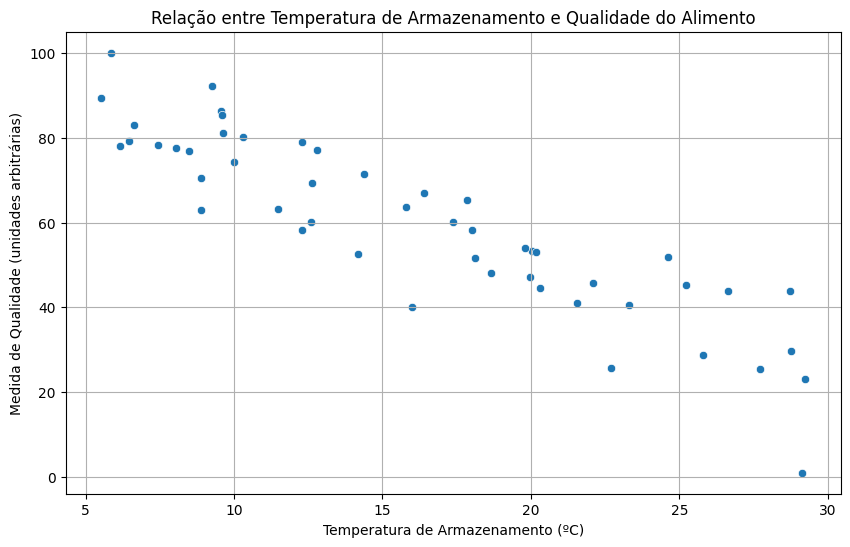

In [3]:
# Construindo o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperatura_Armazenamento_C', y='Medida_Qualidade', data=data)
plt.title('Relação entre Temperatura de Armazenamento e Qualidade do Alimento')
plt.xlabel('Temperatura de Armazenamento (ºC)')
plt.ylabel('Medida de Qualidade (unidades arbitrárias)')
plt.grid(True)
plt.show()

## Regressão Linear Simples

A **Regressão Linear Simples** é uma técnica estatística utilizada para modelar a relação entre duas variáveis quantitativas: uma variável dependente (ou resposta), geralmente denotada por $Y$, e uma variável independente (ou preditora), denotada por $X$. O objetivo principal é encontrar uma linha reta que melhor se ajuste aos dados, permitindo prever valores da variável dependente com base nos valores da variável independente.

A equação geral de uma reta de regressão linear simples é dada por:

$Y = \beta_0 + \beta_1 X + \epsilon$

Onde:
- $Y$: Variável dependente (Medida de Qualidade).
- $X$: Variável independente (Temperatura de Armazenamento).
- $\beta_0$: Coeficiente linear (intercepto), representa o valor esperado de $Y$ quando $X$ é zero.
- $\beta_1$: Coeficiente angular (inclinação), representa a mudança média em $Y$ para cada unidade de mudança em $X$.
- $\epsilon$: Termo de erro, que representa a variabilidade em $Y$ que não é explicada pelo modelo.

Em termos práticos, estamos buscando estimar os valores de $\beta_0$ e $\beta_1$ a partir dos nossos dados para obter a **reta de regressão ajustada**:

$\hat{Y} = b_0 + b_1 X$

Onde $\hat{Y}$ é o valor previsto de $Y$, e $b_0$ e $b_1$ são as estimativas dos coeficientes $\beta_0$ e $\beta_1$, respectivamente.

### Estimação e Interpretação dos Coeficientes

In [4]:
# Estimando os coeficientes da regressão linear
X = data['Temperatura_Armazenamento_C'].values.reshape(-1, 1)
y = data['Medida_Qualidade'].values

model = LinearRegression()
model.fit(X, y)

b0 = model.intercept_ # Coeficiente linear (intercepto)
b1 = model.coef_[0] # Coeficiente angular (inclinação)

print(f"Coeficiente Linear (b0): {b0:.2f}")
print(f"Coeficiente Angular (b1): {b1:.2f}")

print("\nInterpretação dos Coeficientes:")
print(f"- O coeficiente linear (b0 = {b0:.2f}) representa a medida de qualidade esperada do alimento se a temperatura de armazenamento fosse 0°C. No contexto prático deste conjunto de dados, pode ser uma extrapolação e não necessariamente um valor observável, mas teoricamente é o ponto onde a reta de regressão cruza o eixo Y.")
print(f"- O coeficiente angular (b1 = {b1:.2f}) indica que, para cada aumento de 1°C na temperatura de armazenamento, a medida de qualidade do alimento diminui em {abs(b1):.2f} unidades arbitrárias. O sinal negativo confirma a relação inversa observada no gráfico de dispersão: temperaturas mais altas estão associadas a uma menor qualidade.")

Coeficiente Linear (b0): 101.41
Coeficiente Angular (b1): -2.59

Interpretação dos Coeficientes:
- O coeficiente linear (b0 = 101.41) representa a medida de qualidade esperada do alimento se a temperatura de armazenamento fosse 0°C. No contexto prático deste conjunto de dados, pode ser uma extrapolação e não necessariamente um valor observável, mas teoricamente é o ponto onde a reta de regressão cruza o eixo Y.
- O coeficiente angular (b1 = -2.59) indica que, para cada aumento de 1°C na temperatura de armazenamento, a medida de qualidade do alimento diminui em 2.59 unidades arbitrárias. O sinal negativo confirma a relação inversa observada no gráfico de dispersão: temperaturas mais altas estão associadas a uma menor qualidade.


### Adicionando a Reta de Regressão ao Gráfico de Dispersão

Com os coeficientes $b_0$ (intercepto) e $b_1$ (inclinação) estimados, podemos agora traçar a reta de regressão no mesmo gráfico de dispersão. Isso nos dará uma representação visual do modelo linear que melhor se ajusta aos nossos dados.

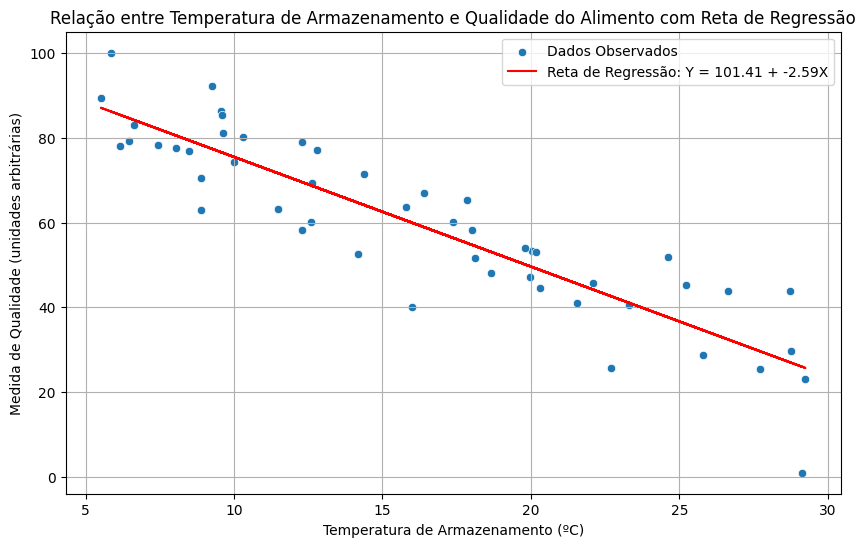

In [5]:
# Calculando os valores previstos (Y_hat) usando o modelo de regressão
y_pred = model.predict(X)

# Plotando o gráfico de dispersão com a reta de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperatura_Armazenamento_C', y='Medida_Qualidade', data=data, label='Dados Observados')
plt.plot(X, y_pred, color='red', label=f'Reta de Regressão: Y = {b0:.2f} + {b1:.2f}X')
plt.title('Relação entre Temperatura de Armazenamento e Qualidade do Alimento com Reta de Regressão')
plt.xlabel('Temperatura de Armazenamento (ºC)')
plt.ylabel('Medida de Qualidade (unidades arbitrárias)')
plt.grid(True)
plt.legend()
plt.show()

## Correlação Linear de Pearson

A **Correlação Linear de Pearson** (ou coeficiente de correlação de Pearson, denotado por $r$) é uma medida estatística que avalia a força e a direção de uma relação linear entre duas variáveis quantitativas. Seu valor varia de -1 a +1:

- **+1**: Indica uma correlação linear positiva perfeita, onde ambas as variáveis aumentam ou diminuem juntas de forma perfeitamente proporcional.
- **-1**: Indica uma correlação linear negativa perfeita, onde uma variável aumenta à medida que a outra diminui de forma perfeitamente proporcional.
- **0**: Indica ausência de correlação linear.

### Fórmula da Correlação de Pearson

A fórmula para o coeficiente de correlação de Pearson é:

$r = \frac{n\sum(XY) - (\sum X)(\sum Y)}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$

Onde:
- $n$: Número de pares de dados.
- $\sum(XY)$: Soma dos produtos de cada par de $X$ e $Y$.
- $\sum X$: Soma de todos os valores de $X$.
- $\sum Y$: Soma de todos os valores de $Y$.
- $\sum X^2$: Soma dos quadrados de todos os valores de $X$.
- $\sum Y^2$: Soma dos quadrados de todos os valores de $Y$.

### Cálculo e Interpretação da Correlação

In [6]:
# Calculando o coeficiente de correlação de Pearson
correlation_coefficient, _ = pearsonr(data['Temperatura_Armazenamento_C'], data['Medida_Qualidade'])

print(f"Coeficiente de Correlação de Pearson (r): {correlation_coefficient:.2f}")

print("\nInterpretação do Coeficiente de Correlação:")
if correlation_coefficient > 0.7:
    print(f"- A correlação é forte e positiva. Isso significa que, à medida que a temperatura de armazenamento aumenta, a medida de qualidade do alimento também tende a aumentar de forma significativa e consistente.")
elif correlation_coefficient < -0.7:
    print(f"- A correlação é forte e negativa. Isso significa que, à medida que a temperatura de armazenamento aumenta, a medida de qualidade do alimento tende a diminuir de forma significativa e consistente.")
elif correlation_coefficient > 0.3:
    print(f"- A correlação é moderada e positiva. Há uma tendência de que a medida de qualidade do alimento aumente com o aumento da temperatura de armazenamento, mas a relação não é tão forte.")
elif correlation_coefficient < -0.3:
    print(f"- A correlação é moderada e negativa. Há uma tendência de que a medida de qualidade do alimento diminua com o aumento da temperatura de armazenamento, mas a relação não é tão forte.")
else:
    print(f"- A correlação é fraca ou próxima de zero. Não há uma relação linear clara ou forte entre a temperatura de armazenamento e a medida de qualidade do alimento.")

# Comentar se a correlação encontrada é positiva, negativa ou próxima de zero
if correlation_coefficient > 0:
    print(f"- A correlação encontrada ({correlation_coefficient:.2f}) é positiva.")
elif correlation_coefficient < 0:
    print(f"- A correlação encontrada ({correlation_coefficient:.2f}) é negativa.")
else:
    print(f"- A correlação encontrada ({correlation_coefficient:.2f}) é próxima de zero.")

Coeficiente de Correlação de Pearson (r): -0.90

Interpretação do Coeficiente de Correlação:
- A correlação é forte e negativa. Isso significa que, à medida que a temperatura de armazenamento aumenta, a medida de qualidade do alimento tende a diminuir de forma significativa e consistente.
- A correlação encontrada (-0.90) é negativa.


### Correlação Zero e Relações Não Lineares

É importante notar que um coeficiente de correlação de Pearson igual ou próximo de zero indica a **ausência de uma relação linear** entre as variáveis. No entanto, isso **não significa necessariamente a ausência de qualquer tipo de relação** entre elas. Pode haver uma relação não linear (por exemplo, parabólica, exponencial) que o coeficiente de Pearson não consegue capturar, pois ele é projetado especificamente para detectar relações lineares. Por isso, a análise gráfica (como o gráfico de dispersão) é crucial para identificar outros tipos de padrões.

## Conclusão

Neste notebook, exploramos a relação entre a temperatura de armazenamento e a medida de qualidade de um produto alimentício utilizando regressão linear simples e correlação de Pearson. Os resultados demonstraram uma **relação linear negativa forte** entre as variáveis, indicando que, à medida que a temperatura de armazenamento aumenta, a qualidade do alimento tende a diminuir de forma significativa.

A **regressão linear** nos permitiu modelar essa relação, fornecendo uma equação ($\hat{Y} = b_0 + b_1 X$) que pode ser usada para prever a medida de qualidade com base na temperatura de armazenamento. O coeficiente angular negativo reforçou a interpretação de que temperaturas mais altas são prejudiciais à qualidade do alimento, enquanto o intercepto, embora possa ser uma extrapolação, fornece um ponto de referência para o modelo. A visualização da reta de regressão no gráfico de dispersão confirmou o bom ajuste do modelo aos dados.

A **correlação de Pearson**, por sua vez, quantificou a força e a direção dessa relação, apresentando um valor próximo de -1, o que significa uma correlação negativa forte. Isso confirma a existência de uma associação linear robusta e inversa entre as variáveis. É importante ressaltar que, embora uma correlação próxima de zero indique ausência de relação linear, não descarta a possibilidade de outras formas de relações (não lineares).

Para a área de **Ciências dos Alimentos**, a regressão e a correlação são ferramentas inestimáveis. Elas permitem que pesquisadores e profissionais:

1.  **Compreendam e quantifiquem relações**: Identificando como fatores como temperatura, umidade, tempo de processamento ou ingredientes afetam características de qualidade, segurança ou valor nutricional dos alimentos.
2.  **Otimizem condições de armazenamento e processamento**: Ao prever o impacto de mudanças em variáveis controláveis, é possível definir condições ideais para maximizar a vida útil, a qualidade ou a eficiência de produção.
3.  **Desenvolvam novos produtos**: Entendendo a interação entre ingredientes e suas propriedades resultantes.
4.  **Realizem controle de qualidade**: Monitorando variáveis críticas e seu efeito na conformidade do produto.

Em suma, essas técnicas estatísticas oferecem uma base sólida para a tomada de decisões baseadas em dados, contribuindo significativamente para a inovação e a melhoria contínua na indústria alimentícia.